In [1]:
!pip install torch-fidelity torchmetrics[image] -q

import os
import glob
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchmetrics.image.fid import FrechetInceptionDistance

torch.manual_seed(42)
np.random.seed(42)
torch.set_float32_matmul_precision('high')

BATCH_SIZE = 64  
MAX_LR = 2e-4     
NUM_EPOCHS = 50   
IMG_SIZE = 64
IN_CHANNELS = 1
PATCH_SIZE = 2    
HIDDEN_SIZE = 256
MODEL_DEPTH = 6
NUM_HEADS = 8

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"INFO: Initializing Flow Matching Engine on {DEVICE}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 2.7 MB/s eta 0:00:00
INFO: Initializing Flow Matching Engine on cuda


/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


In [2]:
test_file = glob.glob('/kaggle/input/datasets/stallio/diffusion-data/**/*.npy', recursive=True)[0]
raw_data = np.load(test_file)
print(f"Original Dataset Image Shape: {raw_data.shape}")

Original Dataset Image Shape: (1, 150, 150)


In [3]:
# DATASET ENGINE
class DeepLenseFlowDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.files = glob.glob(os.path.join(root_dir, "**", "*.npy"), recursive=True)
        
    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx]).astype(np.float32)
        
        # Normalize to [0, 1], then shift to [-1, 1] for stable flow matching
        data = (data - data.min()) / (data.max() - data.min() + 1e-8)
        data = (data * 2.0) - 1.0
        
        data_tensor = torch.from_numpy(data)
        if data_tensor.dim() == 2:
            data_tensor = data_tensor.unsqueeze(0)
            
        # Ensure exact dimensions via interpolation if necessary
        if data_tensor.shape[-1] != IMG_SIZE:
            data_tensor = F.interpolate(data_tensor.unsqueeze(0), size=(IMG_SIZE, IMG_SIZE), mode='bilinear').squeeze(0)
            
        return data_tensor

data_dir = '/kaggle/input/datasets/stallio/diffusion-data'
if not os.path.exists(data_dir):
    print(f"WARNING: Dataset path {data_dir} not found. Using dummy data for testing.")
    dummy_data = [(torch.randn(1, 64, 64)) for _ in range(BATCH_SIZE * 10)]
    train_loader = DataLoader(dummy_data, batch_size=BATCH_SIZE)
else:
    dataset = DeepLenseFlowDataset(data_dir)
    train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

In [4]:
# PATH A: NANO-DiT FLOW MATCHING BACKBONE

def modulate(x, shift, scale):
    return x * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)

class PatchEmbed(nn.Module):
    def __init__(self, img_size=64, patch_size=2, in_chans=1, embed_dim=256):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        
    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)

class Attention(nn.Module):
    def __init__(self, dim, num_heads=8):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        
    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        x = F.scaled_dot_product_attention(q, k, v)
        return self.proj(x.transpose(1, 2).reshape(B, N, C))

class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, in_features)
        
    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))

class TimestepEmbedder(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(256, hidden_size), 
            nn.SiLU(), 
            nn.Linear(hidden_size, hidden_size)
        )
        
    def forward(self, t):
        half = 128
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
        args = t[:, None].float() * freqs[None]
        embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
        return self.mlp(embedding)

class DiTBlock(nn.Module):
    def __init__(self, hidden_size, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(hidden_size, elementwise_affine=False)
        self.attn = Attention(hidden_size, num_heads=num_heads)
        self.norm2 = nn.LayerNorm(hidden_size, elementwise_affine=False)
        self.mlp = Mlp(hidden_size, hidden_size * 4)
        self.adaLN_modulation = nn.Sequential(nn.SiLU(), nn.Linear(hidden_size, 6 * hidden_size))
        
    def forward(self, x, c):
        shift_msa, scale_msa, gate_msa, shift_mlp, scale_mlp, gate_mlp = self.adaLN_modulation(c).chunk(6, dim=1)
        x = x + gate_msa.unsqueeze(1) * self.attn(modulate(self.norm1(x), shift_msa, scale_msa))
        x = x + gate_mlp.unsqueeze(1) * self.mlp(modulate(self.norm2(x), shift_mlp, scale_mlp))
        return x

class FinalLayer(nn.Module):
    def __init__(self, hidden_size, patch_size, out_channels):
        super().__init__()
        self.norm_final = nn.LayerNorm(hidden_size, elementwise_affine=False)
        self.linear = nn.Linear(hidden_size, patch_size * patch_size * out_channels)
        self.adaLN_modulation = nn.Sequential(nn.SiLU(), nn.Linear(hidden_size, 2 * hidden_size))
        
    def forward(self, x, c):
        shift, scale = self.adaLN_modulation(c).chunk(2, dim=1)
        x = self.linear(modulate(self.norm_final(x), shift, scale))
        return x

class DeepLenseNanoDiT(nn.Module):
    def __init__(self):
        super().__init__()
        self.in_channels = IN_CHANNELS
        self.patch_size = PATCH_SIZE
        
        self.x_embedder = PatchEmbed(IMG_SIZE, PATCH_SIZE, IN_CHANNELS, HIDDEN_SIZE)
        self.t_embedder = TimestepEmbedder(HIDDEN_SIZE)
        self.pos_embed = nn.Parameter(torch.randn(1, self.x_embedder.num_patches, HIDDEN_SIZE) * 0.02)
        
        self.blocks = nn.ModuleList([DiTBlock(HIDDEN_SIZE, NUM_HEADS) for _ in range(MODEL_DEPTH)])
        self.final_layer = FinalLayer(HIDDEN_SIZE, PATCH_SIZE, IN_CHANNELS)

        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)

    def forward(self, x, t):
        x = self.x_embedder(x) + self.pos_embed
        c = self.t_embedder(t)
        
        for block in self.blocks: 
            x = block(x, c)
            
        x = self.final_layer(x, c)
        
        B = x.shape[0]
        P = self.patch_size
        H = W = int(x.shape[1] ** 0.5)
        x = x.view(B, H, W, P, P, self.in_channels).permute(0, 5, 1, 3, 2, 4).contiguous()
        return x.view(B, self.in_channels, H * P, W * P)

In [5]:
# EXECUTION BLOCK
model = DeepLenseNanoDiT().to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=MAX_LR)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=MAX_LR, steps_per_epoch=len(train_loader), epochs=NUM_EPOCHS)
criterion_flow = nn.MSELoss()
scaler = torch.amp.GradScaler('cuda')

print("INFO: Commencing Continuous Flow Matching Training...")
for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    total_loss = 0
    
    for inputs in tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS}'):
        inputs = inputs.to(DEVICE)
        batch_size_cur = inputs.shape[0]
        
        noise = torch.randn_like(inputs).to(DEVICE)
        t = torch.rand(batch_size_cur).to(DEVICE)
        t_view = t.view(-1, 1, 1, 1)
        
        # Linear Interpolation (Flow)
        x_t = (1 - t_view) * inputs + t_view * noise
        v_true = noise - inputs
        
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            v_pred = model(x_t, t)
            loss = criterion_flow(v_pred, v_true)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        
        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch} | Avg Flow Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")

print("INFO: Flow Training Complete.")
torch.save(model.state_dict(), '/kaggle/working/flow_engine_weights.pth')

INFO: Commencing Continuous Flow Matching Training...


Epoch 1/50: 100%|██████████| 157/157 [01:20<00:00,  1.95it/s]


Epoch 1 | Avg Flow Loss: 0.8218 | LR: 1.01e-05


Epoch 2/50: 100%|██████████| 157/157 [01:23<00:00,  1.87it/s]


Epoch 2 | Avg Flow Loss: 0.3649 | LR: 1.63e-05


...

Epoch 48 | Avg Flow Loss: 0.0329 | LR: 1.60e-06


Epoch 49/50: 100%|██████████| 157/157 [01:23<00:00,  1.87it/s]


Epoch 49 | Avg Flow Loss: 0.0320 | LR: 3.98e-07


Epoch 50/50: 100%|██████████| 157/157 [01:23<00:00,  1.87it/s]


Epoch 50 | Avg Flow Loss: 0.0333 | LR: 8.16e-10
INFO: Flow Training Complete.



INFO: Generating 4x4 Visual Samples Grid...


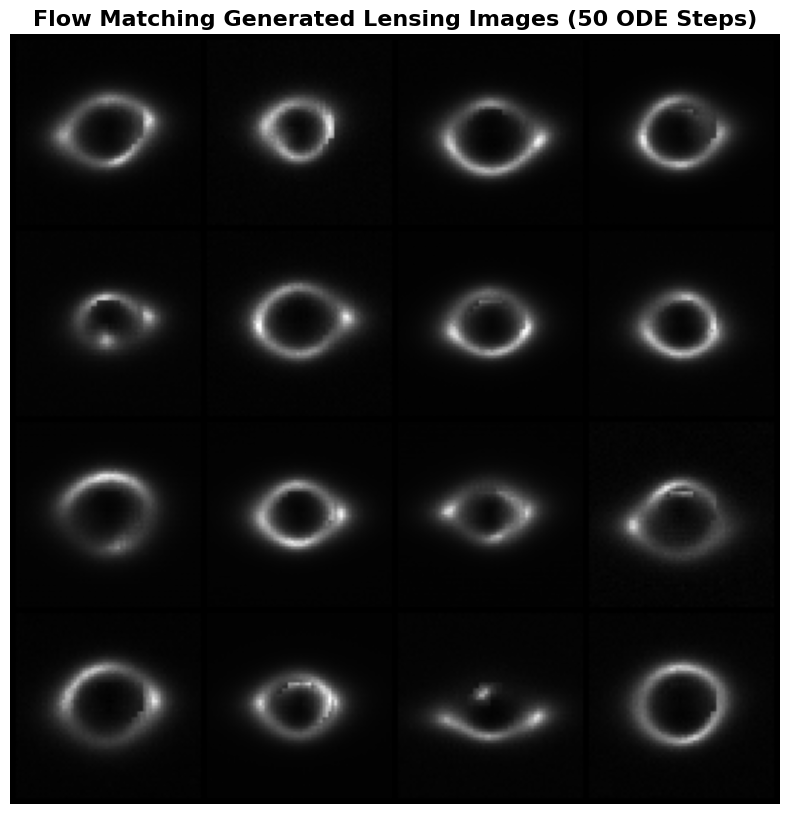


INFO: Running Generation Showdown (ODE vs Math Hack)...


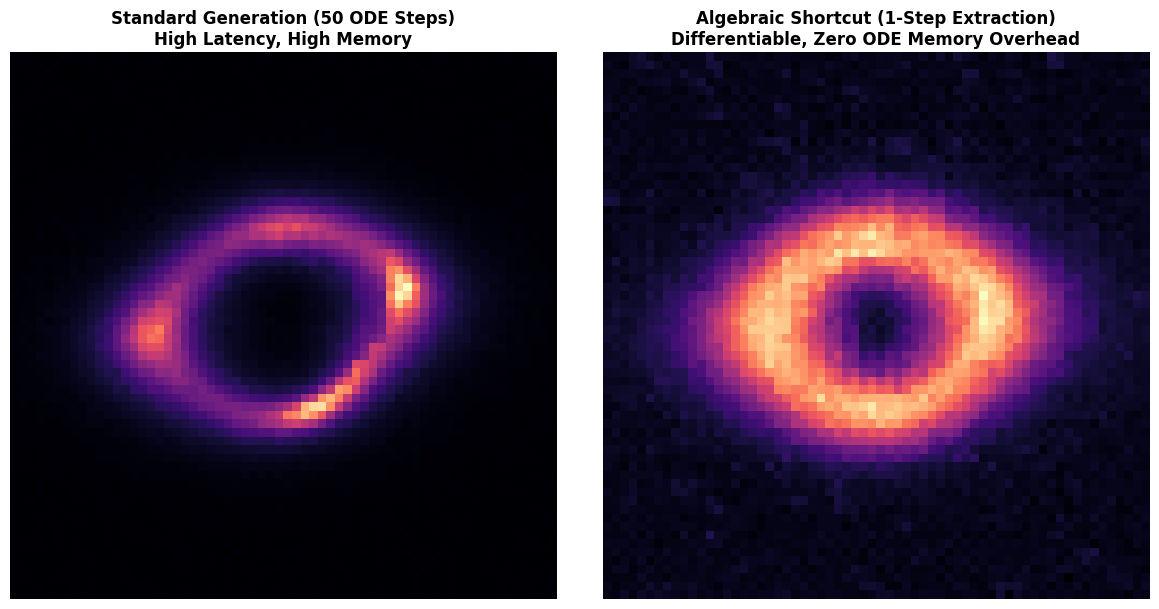

In [6]:
# SAMPLING
@torch.no_grad()
def generate_samples(model, num_samples=1, steps=50):
    model.eval()
    z = torch.randn(num_samples, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
    dt = 1.0 / steps
    for i in range(steps, 0, -1):
        t_val = i / steps
        t = torch.tensor([t_val] * num_samples).to(DEVICE)
        v_pred = model(z, t)
        z = z - dt * v_pred
    model.train()
    return torch.clamp(z, -1.0, 1.0)

@torch.no_grad()
def generate_hack(model, num_samples=1):
    model.eval()
    z_1 = torch.randn(num_samples, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
    t_1 = torch.tensor([1.0] * num_samples).to(DEVICE)
    v_pred = model(z_1, t_1)
    x_pred = z_1 - (1.0 * v_pred) # The Algebraic Shortcut
    model.train()
    return torch.clamp(x_pred, -1.0, 1.0)

# Generate 4x4 Grid
print("\nINFO: Generating 4x4 Visual Samples Grid...")
num_plot_samples = 16
generated_images = generate_samples(model, num_samples=num_plot_samples, steps=50)

generated_images_01 = (generated_images + 1.0) / 2.0
grid = torchvision.utils.make_grid(generated_images_01, nrow=4)
plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.title("Flow Matching Generated Lensing Images (50 ODE Steps)", fontsize=16, fontweight='bold')
plt.axis("off")
plt.show()

# ODE vs Hack Showdown
print("\nINFO: Running Generation Showdown (ODE vs Math Hack)...")
ode_img = generated_images[0:1] 
hack_img = generate_hack(model, num_samples=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(ode_img[0, 0].cpu().numpy(), cmap='magma')
axes[0].set_title("Standard Generation (50 ODE Steps)\nHigh Latency, High Memory", fontsize=12, fontweight='bold')
axes[0].axis('off')
axes[1].imshow(hack_img[0, 0].cpu().numpy(), cmap='magma')
axes[1].set_title("Algebraic Shortcut (1-Step Extraction)\nDifferentiable, Zero ODE Memory Overhead", fontsize=12, fontweight='bold')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [7]:
# EVALUTION BLOCK
print("\nINFO: Running Official Benchmarks...")

def prepare_images_for_fid(images):
    if images.size(1) == 1:
        images = images.repeat(1, 3, 1, 1)
    images = (images + 1.0) / 2.0  
    return (images * 255).clamp(0, 255).to(torch.uint8)

def calculate_fid_score(real_dataloader, model, num_samples=2500, batch_size=32):
    fid = FrechetInceptionDistance(normalize=False).to(DEVICE)
    
    real_images = []
    for data in tqdm(real_dataloader, desc="Collecting real images"):
        real_images.append(data.cpu())
        if len(torch.cat(real_images)) >= num_samples:
            break
    real_images = torch.cat(real_images, dim=0)[:num_samples]
    
    generated_images = []
    for i in tqdm(range(0, num_samples, batch_size), desc="Generating samples"):
        current_batch = min(batch_size, num_samples - i)
        samples = generate_samples(model, num_samples=current_batch, steps=50)
        generated_images.append(samples.cpu())
        torch.cuda.empty_cache()
    generated_images = torch.cat(generated_images, dim=0)[:num_samples]
    
    for i in range(0, num_samples, batch_size):
        end_idx = min(i + batch_size, num_samples)
        real_batch = prepare_images_for_fid(real_images[i:end_idx]).to(DEVICE)
        fid.update(real_batch, real=True)
        gen_batch = prepare_images_for_fid(generated_images[i:end_idx]).to(DEVICE)
        fid.update(gen_batch, real=False)
        torch.cuda.empty_cache()
        
    return fid.compute().item()

# RUN FID
try:
    if os.path.exists(data_dir):
        fid_score = calculate_fid_score(train_loader, model, num_samples=2500, batch_size=32)
        print(f"FID score: {fid_score:.4f}")
except Exception as e:
    print(f"FID Calculation failed: {e}")

# RUN LATENCY SHOWDOWN
print("\nINFO: Running Latency Benchmark...")
start_event, end_event = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
iters = 100

start_event.record()
for _ in tqdm(range(iters), desc="Benchmarking 50-Step ODE"):
    generate_samples(model, num_samples=1, steps=50)
end_event.record()
torch.cuda.synchronize()
ode_time = start_event.elapsed_time(end_event) / iters

start_event.record()
for _ in tqdm(range(iters), desc="Benchmarking 1-Step Hack"):
    generate_hack(model, num_samples=1)
end_event.record()
torch.cuda.synchronize()
hack_time = start_event.elapsed_time(end_event) / iters

print(f"LATENCY RESULTS:")
print(f"Standard 50-Step ODE Latency : {ode_time:.4f} ms")
print(f"1-Step Algebraic Hack Latency: {hack_time:.4f} ms")
print(f"Speedup Multiplier           : {ode_time / hack_time:.1f}x Faster!")


INFO: Running Official Benchmarks...


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 248MB/s]
Generating samples: 100%|██████████| 79/79 [15:49<00:00, 12.02s/it]


FID score: 48.1796

INFO: Running Latency Benchmark...


Benchmarking 1-Step Hack: 100%|██████████| 100/100 [00:00<00:00, 114.76it/s]

LATENCY RESULTS:
Standard 50-Step ODE Latency : 439.3591 ms
1-Step Algebraic Hack Latency: 8.7704 ms
Speedup Multiplier           : 50.1x Faster!
